In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
from scipy.stats import mannwhitneyu

In [4]:
cell_proportions=pd.read_csv("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/bp_res_mid_lvl_ct_updated_ct_fraction_batch_3.csv")
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/fibroblasts_gene_expression_data_new_batch_three_merged_transposed.csv")
print(len(fibr_gene_expression_modified))
cell_proportions=pd.read_csv("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged_new/bp_res_mid_lvl_ct_updated_ct_fraction_batch_3.csv")
fibr_gene_expression_modified = pd.merge(
    fibr_gene_expression_modified,
    cell_proportions,
    on="dcc_filename",
    how="inner"  # or "left", "right", "outer" depending on your needs
)
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/Lab_stuff/batch_merged/9_eyemt_patient_clinical_data_new.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b123","OS_quartile_b123"]],on="Patient", how="left")
fibr_gene_expression_cell_abundance=fibr_gene_expression_modified.merge(cell_proportions, on="dcc_filename", how="left")

1130


In [5]:
cell_proportions["Segment_geomx"]

0          tsi
1          tsi
2          tsi
3          tsi
4          tsi
         ...  
1144       tsi
1145       tsi
1146       tsi
1147    stroma
1148    stroma
Name: Segment_geomx, Length: 1149, dtype: object

In [6]:
cell_types=[
 'Tcells_reg',
 'Bcells',
 'Fibroblasts',
 'NKcells',
 'Tcells_CD8',
 'Tcells_CD4',
 'Macrophages_Monocytes',
 #'Mast_cells',
 'DCs',
 #'Tcells_other',
 'Endothelial_cells',]

In [7]:
fibr_gene_expression_cell_abundance["PFS_HL_group"] = fibr_gene_expression_cell_abundance["PFS_quartile_b123"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)
fibr_gene_expression_cell_abundance["OS_HL_group"] = fibr_gene_expression_cell_abundance["OS_quartile_b123"].apply(
    lambda x: "Low" if x in [1, "1", 2, "2"] else ("High" if x in [3, "3", 4, "4"] else None)
)

In [8]:
# Properly filter for stroma + Segment_geomx == 'tsi'
stroma_cell_abundance = cell_proportions[
    (cell_proportions['Segment'] == 'stroma') & 
    (cell_proportions['Segment_geomx'] == 'stroma')
]

# Seems to be the same filter as above — do you really need both?
stroma_tsi_cell_abundance = cell_proportions[
    (cell_proportions['Segment'] == 'stroma') & 
    (cell_proportions['Segment_geomx'] == 'tsi')
]

# Group by Sample_y and compute mean abundance
average_stroma_cell_abundance_stroma = stroma_cell_abundance.groupby('Sample')[cell_types].mean()
average_stroma_cell_abundance_stroma["Segment_geomx"] = "stroma"
average_stroma_cell_abundance_tsi = stroma_tsi_cell_abundance.groupby('Sample')[cell_types].mean()
average_stroma_cell_abundance_tsi["Segment_geomx"] = "tsi"



In [10]:
combined=pd.concat([average_stroma_cell_abundance_stroma,average_stroma_cell_abundance_tsi])


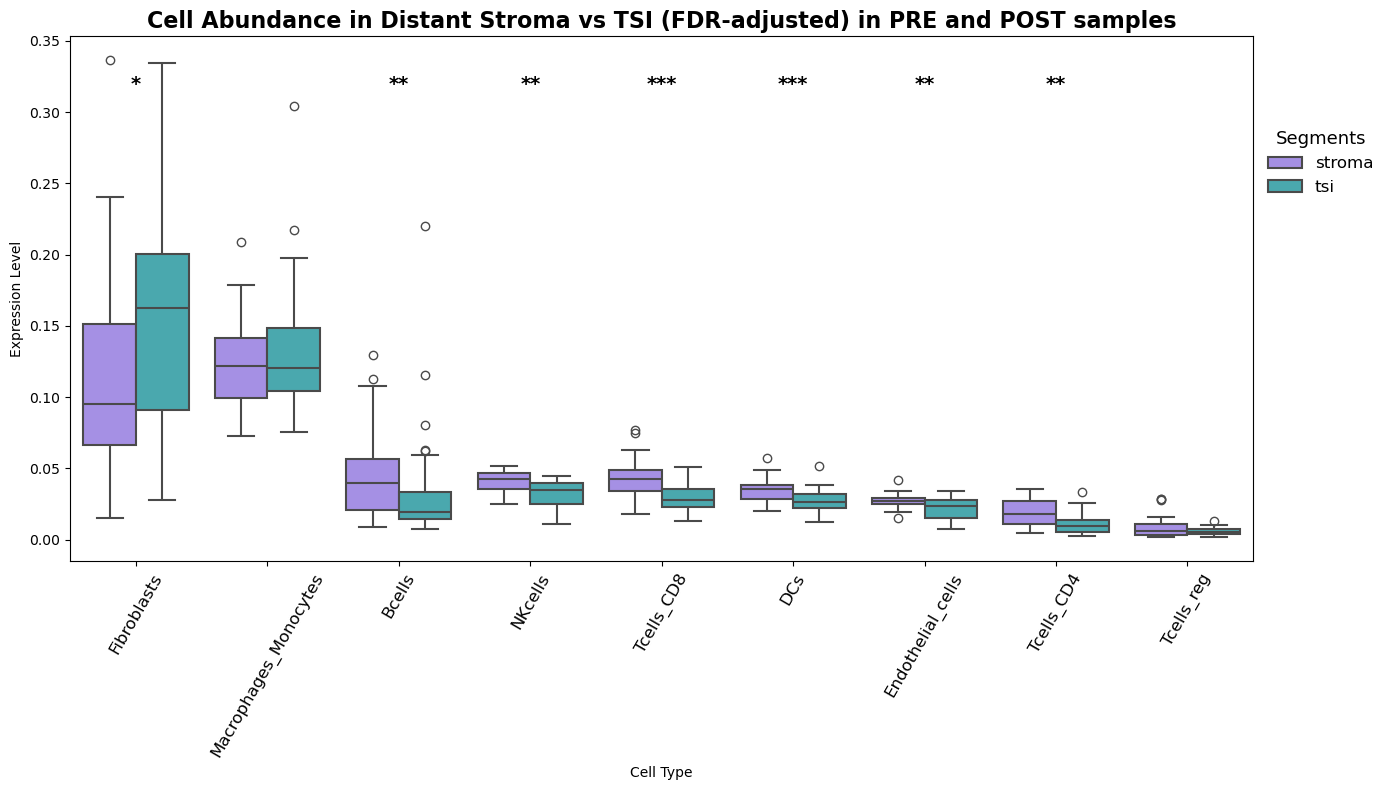

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

# =========================
# 1. Statistical testing per cell type
# =========================
results = {}
for cell in cell_types:
    group_stroma = combined.loc[combined["Segment_geomx"] == "stroma", cell].dropna()
    group_tsi    = combined.loc[combined["Segment_geomx"] == "tsi", cell].dropna()
    
    stat, p_value = mannwhitneyu(group_stroma, group_tsi, alternative="two-sided")
    
    results[cell] = {
        "stroma_mean": group_stroma.mean(),
        "tsi_mean": group_tsi.mean(),
        "p_value": p_value,
        "mean_total": pd.concat([group_stroma, group_tsi]).mean()
    }

res_df = pd.DataFrame(results).T

# FDR correction
res_df["p_adj"] = multipletests(res_df["p_value"], method="fdr_bh")[1]

# =========================
# 2. Sort cell types by total mean abundance
# =========================
sorted_cells = res_df.sort_values(by="mean_total", ascending=False).index.tolist()

# =========================
# 3. Prepare data for plotting
# =========================
plot_data = pd.melt(
    combined.loc[combined["Segment_geomx"].isin(["stroma", "tsi"])],
    id_vars=["Segment_geomx"],
    value_vars=sorted_cells,
    var_name="Cell_Type",
    value_name="Expression"
)

# =========================
# 4. Plot
# =========================
plt.figure(figsize=(14, 8))
palette = {"stroma":"#9e82f2", "tsi": "#3ab7be"}

ax = sns.boxplot(
    x="Cell_Type", y="Expression", hue="Segment_geomx", 
    data=plot_data, palette=palette, linewidth=1.5, order=sorted_cells
)

# =========================
# 5. Add FDR-adjusted significance stars
# =========================
y_max = plot_data["Expression"].max()
for i, cell in enumerate(sorted_cells):
    p_adj = res_df.loc[cell, "p_adj"]
    if p_adj < 0.05:
        if p_adj >= 0.01:
            star = "*"
        elif p_adj >= 0.001:
            star = "**"
        else:
            star = "***"
        ax.text(i, y_max*0.95, star, ha="center", va="center", fontsize=14, fontweight="bold", color="black")

# =========================
# 6. Labels and formatting
# =========================
plt.title("Cell Abundance in Distant Stroma vs TSI (FDR-adjusted) in PRE and POST samples", fontsize=16, fontweight="bold")
plt.xlabel("Cell Type")
plt.ylabel("Expression Level")
plt.xticks(rotation=60, fontsize=12)

# =========================
# 7. Legends
# =========================
# Segment legend (stroma vs TSI)
handles, labels = ax.get_legend_handles_labels()
segment_handles = handles[:2]  # first two are stroma/tsi
segment_labels = ["stroma", "tsi"]
legend1 = ax.legend(handles=segment_handles, labels=segment_labels,
                    title="Segments", title_fontsize=13, fontsize=12,
                    loc='upper left', bbox_to_anchor=(1.0, 0.85), frameon=False)

# Add significance legend (FDR stars) without removing segment legend
'''
signif_legend = [
    Patch(facecolor="none", edgecolor="none", label="*   FDR < 0.05"),
    Patch(facecolor="none", edgecolor="none", label="**  FDR < 0.01"),
    Patch(facecolor="none", edgecolor="none", label="*** FDR < 0.001"),
]
ax.add_artist(legend1)  # keep first legend
ax.add_artist(plt.legend(handles=signif_legend, loc="upper left", bbox_to_anchor=(1.0, 1.05), frameon=False))
'''

plt.tight_layout()
plt.show()

/var/folders/5f/jg_zhw0n3xl1tf79w0wk705r0000gn/T/ipykernel_8594/1946366010.py:57: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


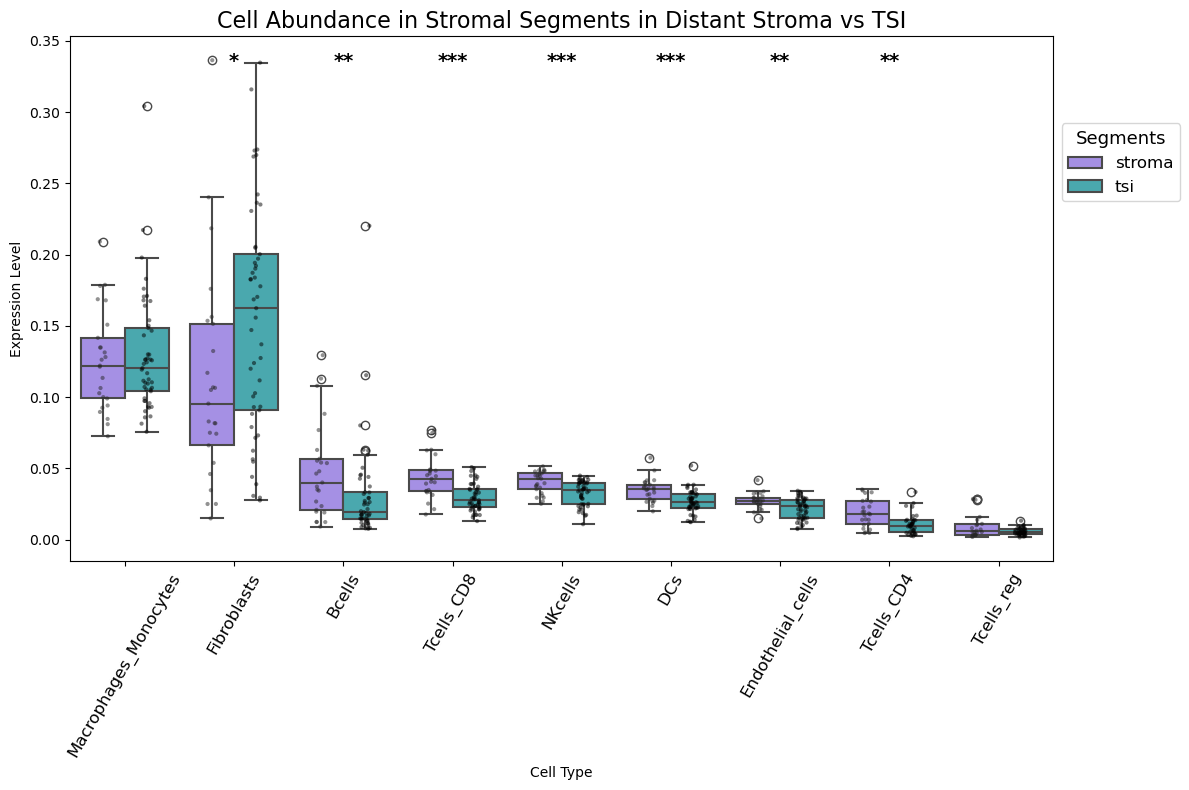

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from matplotlib.patches import Patch

# -----------------------------
# 1. Compute stats per cell type
# -----------------------------
results = {}
for cell in cell_types:
    group_stroma = combined.loc[combined["Segment_geomx"] == "stroma", cell].dropna()
    group_tsi    = combined.loc[combined["Segment_geomx"] == "tsi", cell].dropna()

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_stroma, group_tsi, alternative="two-sided")

    results[cell] = {
        "stroma_mean": group_stroma.mean(),
        "tsi_mean": group_tsi.mean(),
        "p_value": p_value
    }

# Convert to DataFrame
res_df = pd.DataFrame(results).T

# -----------------------------
# 2. Sort cell types by stroma mean abundance
# -----------------------------
sorted_cells = res_df.sort_values(by="stroma_mean", ascending=False).index.tolist()

# -----------------------------
# 3. Prepare data for plotting
# -----------------------------
plot_data = pd.melt(
    combined.loc[combined["Segment_geomx"].isin(["stroma", "tsi"])], 
    id_vars=["Segment_geomx"], 
    value_vars=sorted_cells,  # use sorted order here
    var_name="Cell_Type", 
    value_name="Expression"
)

# -----------------------------
# 4. Plot boxplots
# -----------------------------
plt.figure(figsize=(12, 8))

palette = {"tsi": "#3ab7be", "stroma": "#9e82f2"}

ax = sns.boxplot(
    x="Cell_Type", y="Expression", hue="Segment_geomx", data=plot_data, 
    palette=palette, linewidth=1.5
)

''''''
sns.stripplot(
    x="Cell_Type", y="Expression", hue="Segment_geomx", data=plot_data,
    dodge=True, color="black", alpha=0.5, size=3
)
''''''

# -----------------------------
# 5. Add significance stars
# -----------------------------
for i, cell in enumerate(sorted_cells):
    p = res_df.loc[cell, "p_value"]
    if p < 0.05:
        star = "*" if p >= 0.01 else "**" if p >= 0.001 else "***"
        ax.text(i, ax.get_ylim()[1]*0.95, star, color="black", ha="center", va="center", fontsize=14, fontweight="bold")

# -----------------------------
# 6. Labels and title
# -----------------------------
plt.title("Cell Abundance in Stromal Segments in Distant Stroma vs TSI", fontsize=16)
plt.xlabel("Cell Type")
plt.xticks(fontsize=12, rotation=60)
plt.ylabel("Expression Level")

# -----------------------------
# 7. Custom legends
# -----------------------------
custom_legend = [
    Patch(facecolor="none", edgecolor="none", label="*   p < 0.05"),
    Patch(facecolor="none", edgecolor="none", label="**  p < 0.01"),
    Patch(facecolor="none", edgecolor="none", label="*** p < 0.001")
]
ax.legend(handles=custom_legend, loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

# Legend for stroma vs TSI
handles, labels = ax.get_legend_handles_labels()
handles = [handles[0], handles[1]]  # Stroma and TSI colors
labels = ["stroma", "tsi"]
ax.legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(1.0, 0.85), title="Segments", title_fontsize=13, fontsize=12)

plt.tight_layout()
plt.show()


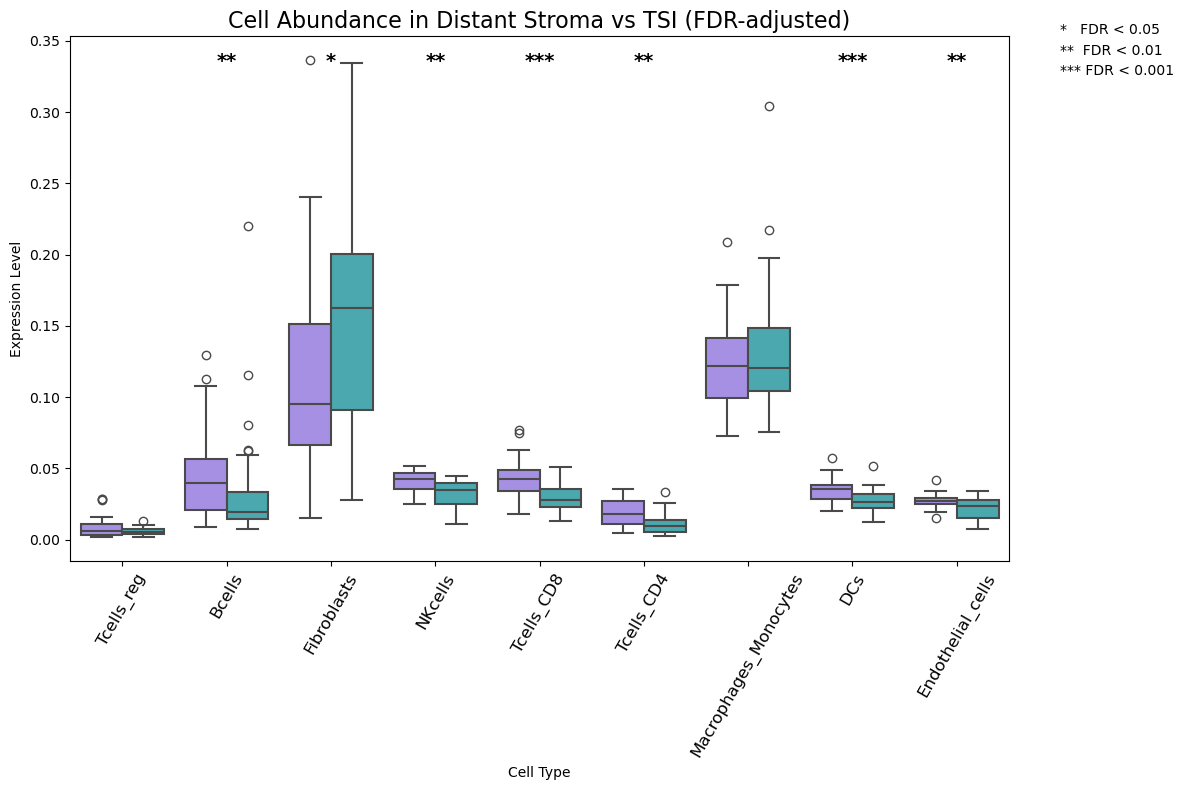

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

# =========================
# Statistical testing
# =========================

results = {}

for cell in cell_types:
    group_stroma = combined.loc[
        combined["Segment_geomx"] == "stroma", cell
    ].dropna()

    group_tsi = combined.loc[
        combined["Segment_geomx"] == "tsi", cell
    ].dropna()

    # Mann–Whitney U test (two-sided)
    stat, p_value = mannwhitneyu(
        group_stroma, group_tsi, alternative="two-sided"
    )

    results[cell] = {
        "stroma_mean": group_stroma.mean(),
        "tsi_mean": group_tsi.mean(),
        "p_value": p_value
    }

# Convert to DataFrame
res_df = pd.DataFrame(results).T

# =========================
# Multiple testing correction
# =========================

res_df["p_adj"] = multipletests(
    res_df["p_value"],
    method="fdr_bh"
)[1]

# =========================
# Prepare data for plotting
# =========================

plot_data = pd.melt(
    combined.loc[combined["Segment_geomx"].isin(["stroma", "tsi"])],
    id_vars=["Segment_geomx"],
    value_vars=cell_types,
    var_name="Cell_Type",
    value_name="Expression"
)

# =========================
# Plot
# =========================

plt.figure(figsize=(12, 8))



#palette = {
#    "stroma": "#65D5DF",  # cyan
#    "tsi": "#DB615C"      # red
#}


palette={"tsi": "#3ab7be", "stroma":"#9e82f2"}

ax = sns.boxplot(
    x="Cell_Type",
    y="Expression",
    hue="Segment_geomx",
    data=plot_data,
    palette=palette,
    linewidth=1.5
)

# =========================
# Add FDR-adjusted significance stars
# =========================

y_max = ax.get_ylim()[1]

for i, cell in enumerate(cell_types):
    p_adj = res_df.loc[cell, "p_adj"]

    if p_adj < 0.05:
        if p_adj >= 0.01:
            star = "*"
        elif p_adj >= 0.001:
            star = "**"
        else:
            star = "***"

        ax.text(
            i,
            y_max * 0.95,
            star,
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

# =========================
# Labels and formatting
# =========================

plt.title(
    "Cell Abundance in Distant Stroma vs TSI (FDR-adjusted)",
    fontsize=16
)
plt.xlabel("Cell Type")
plt.ylabel("Expression Level")
plt.xticks(rotation=60, fontsize=12)

# =========================
# Legends
# =========================

# Segment legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles[:2],
    labels=["stroma", "tsi"],
    title="Segments",
    title_fontsize=13,
    fontsize=12,
    loc="upper left",
    bbox_to_anchor=(1.0, 0.85),
    frameon=False
)

# Significance legend
signif_legend = [
    Patch(facecolor="none", edgecolor="none", label="*   FDR < 0.05"),
    Patch(facecolor="none", edgecolor="none", label="**  FDR < 0.01"),
    Patch(facecolor="none", edgecolor="none", label="*** FDR < 0.001"),
]

ax.legend(
    handles=signif_legend,
    loc="upper left",
    bbox_to_anchor=(1.0, 1.05),
    frameon=False
)

plt.tight_layout()
plt.show()


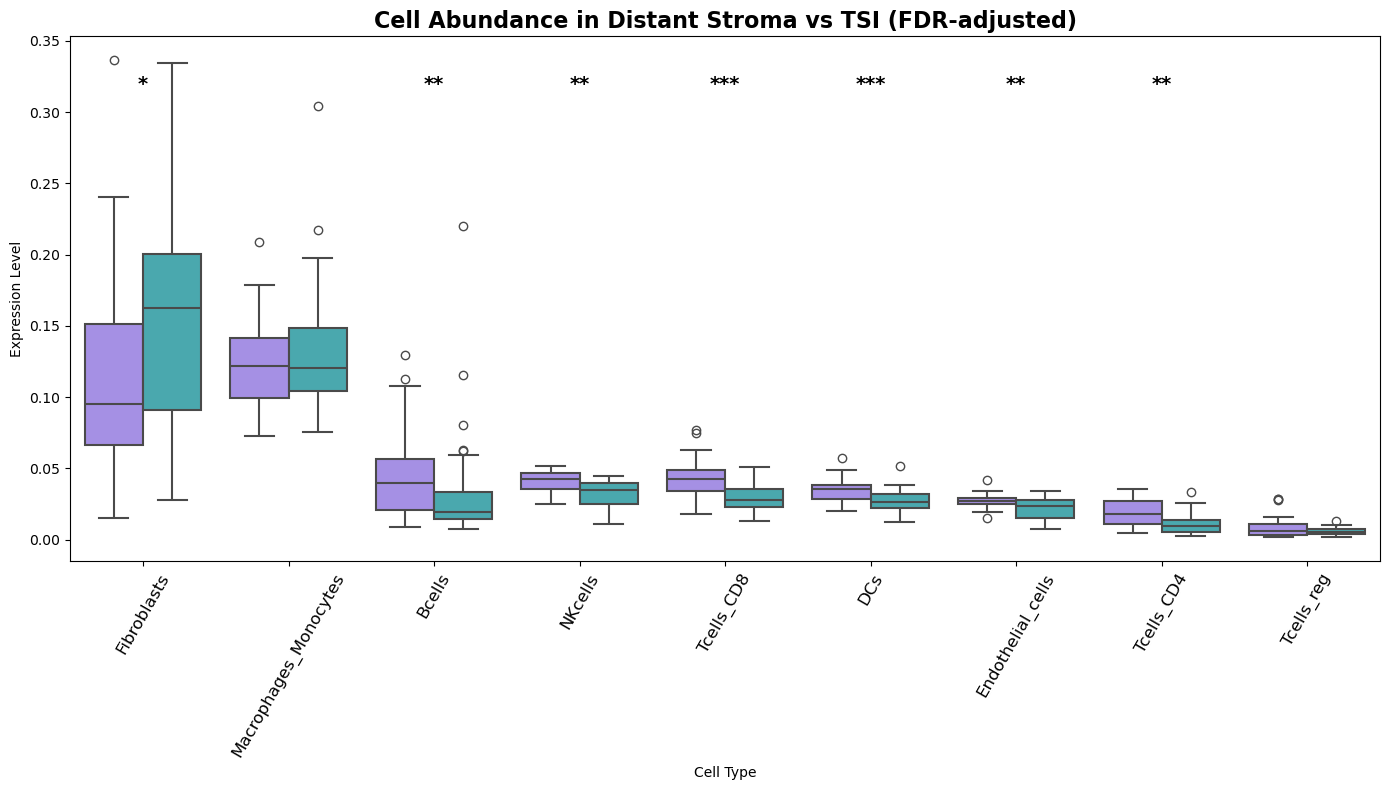

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

# =========================
# 1. Statistical testing per cell type
# =========================
results = {}

for cell in cell_types:
    group_stroma = combined.loc[combined["Segment_geomx"] == "stroma", cell].dropna()
    group_tsi    = combined.loc[combined["Segment_geomx"] == "tsi", cell].dropna()
    
    stat, p_value = mannwhitneyu(group_stroma, group_tsi, alternative="two-sided")
    
    results[cell] = {
        "stroma_mean": group_stroma.mean(),
        "tsi_mean": group_tsi.mean(),
        "p_value": p_value,
        "mean_total": pd.concat([group_stroma, group_tsi]).mean()
    }

res_df = pd.DataFrame(results).T

# FDR correction
res_df["p_adj"] = multipletests(res_df["p_value"], method="fdr_bh")[1]

# =========================
# 2. Sort cell types by total mean abundance
# =========================
sorted_cells = res_df.sort_values(by="mean_total", ascending=False).index.tolist()

# =========================
# 3. Prepare data for plotting
# =========================
plot_data = pd.melt(
    combined.loc[combined["Segment_geomx"].isin(["stroma", "tsi"])],
    id_vars=["Segment_geomx"],
    value_vars=sorted_cells,
    var_name="Cell_Type",
    value_name="Expression"
)

# =========================
# 4. Plot
# =========================
plt.figure(figsize=(14, 8))
palette = {"stroma":"#9e82f2", "tsi": "#3ab7be"}

ax = sns.boxplot(
    x="Cell_Type", y="Expression", hue="Segment_geomx", 
    data=plot_data, palette=palette, linewidth=1.5, order=sorted_cells
)


'''
sns.stripplot(
    x="Cell_Type", y="Expression", hue="Segment_geomx", 
    data=plot_data, dodge=True, color="black", alpha=0.5, size=3, order=sorted_cells
)
'''

# =========================
# 5. Add FDR-adjusted significance stars
# =========================
y_max = plot_data["Expression"].max()
for i, cell in enumerate(sorted_cells):
    p_adj = res_df.loc[cell, "p_adj"]
    if p_adj < 0.05:
        if p_adj >= 0.01:
            star = "*"
        elif p_adj >= 0.001:
            star = "**"
        else:
            star = "***"
        ax.text(i, y_max*0.95, star, ha="center", va="center", fontsize=14, fontweight="bold", color="black")

# =========================
# 6. Labels and formatting
# =========================
plt.title("Cell Abundance in Distant Stroma vs TSI (FDR-adjusted)", fontsize=16, fontweight="bold")
plt.xlabel("Cell Type")
plt.ylabel("Expression Level")
plt.xticks(rotation=60, fontsize=12)

# =========================
# 7. Legends
# =========================
# Segment legend
handles, labels = ax.get_legend_handles_labels()
handles = handles[:2]  # first two are stroma/tsi
labels = ["stroma", "tsi"]
ax.legend(handles=handles, labels=labels, title="Segments", title_fontsize=13, fontsize=12,
          loc="upper left", bbox_to_anchor=(1.0, 0.85), frameon=False)

# Significance legend
signif_legend = [
    Patch(facecolor="none", edgecolor="none", label="*   FDR < 0.05"),
    Patch(facecolor="none", edgecolor="none", label="**  FDR < 0.01"),
    Patch(facecolor="none", edgecolor="none", label="*** FDR < 0.001"),
]
ax.add_artist(plt.legend(handles=signif_legend, loc="upper left", bbox_to_anchor=(1.0, 1.05), frameon=False))

plt.tight_layout()
plt.show()
